testing

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math
from matplotlib.path import Path

In [2]:
#global variable
objects = []   # stores all objects

#ray class
class Ray:
    step=0.01 
    rays = []
    
    def __init__(self, y_pos, theta, x_pos=0):
        self.ypos = y_pos
        self.xpos = x_pos
        #why must math module do everything in radians????
        self.angle= math.radians(theta)
        self.x_history = [x_pos]
        self.y_history = [y_pos]

        #starts in air
        self.n_ofMedium=1
        
                
        Ray.rays.append(self)
        objects.append(self)
        
    #move small amount in direction theta
    def move_step(self):
        self.ypos=self.ypos+Ray.step*math.sin(self.angle)
        self.xpos=self.xpos+Ray.step*math.cos(self.angle)
        
        self.x_history.append(self.xpos)
        self.y_history.append(self.ypos) 

        for obj in objects: 
            if isinstance(obj,PerpSurface):
                if self.xpos>=obj.xStartPos and self.xpos<=obj.xEndPos and self.n_ofMedium!=obj.refractiveIndex:
                    self.angle = math.asin(self.n_ofMedium*math.sin(self.angle)/obj.refractiveIndex)
                    self.n_ofMedium=obj.refractiveIndex
    
    #display all instance attributes 
    def display(self):
        print(f"xpos: {self.xpos}, ypos: {self.ypos}, angle: {self.angle}")

    @classmethod
    def move_all(cls):
        for ray in cls.rays:
            ray.move_step()

In [3]:
#surfaces
class PerpSurface:
    def __init__(self, x_Startpos, x_Endpos, n, color="white"):
        self.xStartPos = x_Startpos
        self.xEndPos = x_Endpos
        
        self.refractiveIndex = n   
        objects.append(self)

        self.color = color


class Circle:
    def __init__(self, x_center, y_center, r, n):
        self.xCenter = x_center
        self.yCenter = y_center
        self.radius=r
        self.refractiveIndex = n
        objects.append(self)
        
        self.x = np.array(np.linspace(self.xCenter-r, self.xCenter+r, num=500))
        self.yPositive = (r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter
        self.yNegative = -1*(r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter


def plotEverything():
    for obj in objects:
        if isinstance(obj, Ray):
            plt.plot(obj.x_history,obj.y_history,"--")
    
        elif isinstance(obj, PerpSurface):
            plt.axvspan(obj.xStartPos, obj.xEndPos, color=obj.color)

        elif isinstance(obj, Circle):
            x_full = np.concatenate([obj.x, obj.x[::-1]])
            y_full = np.concatenate([obj.yPositive, obj.yNegative[::-1]])
            
            plt.fill(x_full, y_full, color="lightblue", alpha=0.4)
    
    # plt.axis("equal")
    plt.show()

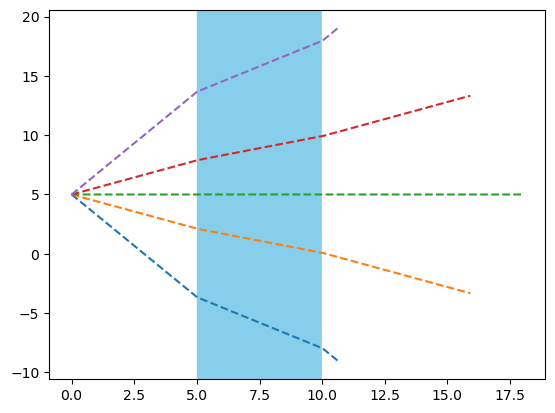

In [4]:
objects = []   #resets, clears the "board"

ray3 = Ray(y_pos=5, theta=-60, x_pos=0)

ray0 = Ray(y_pos=5, theta=-30, x_pos=0)

ray2 = Ray(y_pos=5, theta=0, x_pos=0)

ray2 = Ray(y_pos=5, theta=30, x_pos=0)

ray2 = Ray(y_pos=5, theta=60, x_pos=0)

surface1 = PerpSurface(x_Startpos=0,x_Endpos=5,n=1)
surface2 = PerpSurface(x_Startpos=5,x_Endpos=10,n=1.33,color='skyblue')
surface3 = PerpSurface(x_Startpos=10,x_Endpos=15,n=1)

for i in range(1800):
    Ray.move_all()

plotEverything()